# Project : RESUME CLASSIFICATION using NLP

## Objective
To build an automated Resume Classification System 
that reduces manual effort in HR screening by categorizing resumes into relevant job roles


## Import Libraries

In [1]:
import sys
!{sys.executable} -m pip install python-docx pdfplumber


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np

# TEXT EXTRACTION LIBRARIES
from docx import Document
import pdfplumber

print("Libraries Imported Successfully")

Libraries Imported Successfully


## DATASET UNDERSTANDING 

In [3]:

# Set base folder path (where Resumes folder exists)
base_folder = "Resumes"

In [4]:
# Check if folder exists
print("Does folder exist?", os.path.exists(base_folder))

Does folder exist? True


In [5]:
# List all role folders
print("\nJob Role Folders:")
print(os.listdir(base_folder))


Job Role Folders:
['Internship_Ravali_Musquare Technologies (1).docx', 'Internship_Susovan Bag_Musquare Technologies.docx', 'Peoplesoft resumes', 'React Developer_Deepakreddy.docx', 'React Developer_Haripriya.docx', 'React Developer_Kamalakar Reddy.docx', 'React Developer_Naveen sadhu.docx', 'React Developer_PavasGoswami.doc', 'React Developer_Pragnya.docx', 'React Developer_Sarala Madasu-converted.docx', 'React Developer_Thirupathiamma.docx', 'React Developer_Vinay Reddy.doc', 'React Dev_Krishna Kanth.docx', 'React Dev_Krishna Kanth_Musquare Technologies.docx', 'React JS Developer_AnjaniPriyadarshini.doc', 'React JS Developer_KotaniDurgaprasad[3_1] (1)-converted.docx', 'React JS Developer_Venkatalakshmi (1)-converted.docx', 'Reactjs Developer_kambala sai surendra_Musquare Technologies.docx', 'Reactjs Developer_M Lokesh Babu_Musquare Technologies.docx', 'Reactjs Developer_M Lokesh.docx', 'Reactjs Developer_MD Khizaruddin Rauf _Musquare Technologies.docx', 'Reactjs Developer_Prabakaran

#

### Identify Folder Structure
-  To understand how the dataset is organized before proceeding with resume text extraction.

- In this step, we separate:
1️. Job role folders
2️. Direct resume files placed in main directory

In [6]:
folders = []
files = []

for item in os.listdir(base_folder):
    full_path = os.path.join(base_folder, item)
    
    if os.path.isdir(full_path):
        folders.append(item)   # Identified as job role folder
    else:
        files.append(item)     # Identified as standalone resume file

print("Job Role Folders Identified:")
print(folders)

print("\nStandalone Resume Files (Sample Display):")
print(files[:5])

Job Role Folders Identified:
['Peoplesoft resumes', 'SQL Developer Lightning insight', 'workday resumes']

Standalone Resume Files (Sample Display):
['Internship_Ravali_Musquare Technologies (1).docx', 'Internship_Susovan Bag_Musquare Technologies.docx', 'React Developer_Deepakreddy.docx', 'React Developer_Haripriya.docx', 'React Developer_Kamalakar Reddy.docx']


#

### Role Extraction Logic for Standalone Files

- If file is not inside a folder, extract role from filename
- Example: "React Developer_Name.docx" -> "React Developer"

In [7]:
def extract_role_from_filename(filename):
    if "_" in filename:
        return filename.split("_")[0].strip()
    else:
        return "Unknown"

print("Role extraction function ready.")

Role extraction function ready.


#

### Resume Text Extraction & Dataset Creation

- Read resumes from both folders and standalone files
- Extract text from .docx and .pdf files
- Assign correct job role
- Create structured DataFrame

In [8]:
# Resume Extraction & Structured Dataset Creation

data = []
total_files = 0
read_files = 0
skipped_files = 0

for root, dirs, files_list in os.walk(base_folder):
    for file in files_list:
        total_files += 1
        file_path = os.path.join(root, file)
        text = ""

        # ---- Read DOCX ----
        if file.lower().endswith(".docx"):
            try:
                doc = Document(file_path)
                text = " ".join(p.text for p in doc.paragraphs)
                read_files += 1
            except:
                skipped_files += 1
                continue

        # ---- Read PDF ----
        elif file.lower().endswith(".pdf"):
            try:
                with pdfplumber.open(file_path) as pdf:
                    text = " ".join(page.extract_text() or "" for page in pdf.pages)
                read_files += 1
            except:
                skipped_files += 1
                continue
        else:
            skipped_files += 1
            continue

        # ---- Assign Role ----
        # If inside subfolder -> role = folder name
        # If in main folder -> extract from filename
        relative_path = os.path.relpath(root, base_folder)
        
        if relative_path != ".":
            role = relative_path.split(os.sep)[0]
        else:
            role = extract_role_from_filename(file)

        if text.strip():
            data.append({
                "resume_text": text,
                "job_title": role,
                "file_name": file
            })

df = pd.DataFrame(data)

print("Total files found:", total_files)
print("Readable resumes:", read_files)
print("Skipped files:", skipped_files)
print("Final dataset size:", df.shape)

Total files found: 79
Readable resumes: 53
Skipped files: 26
Final dataset size: (53, 3)


In [9]:
# Role Distribution Analysis

# This step checks how many resumes are present for each job role.
# It helps us understand whether the dataset is balanced.

print("Number of resumes per job role:\n")
print(df['job_title'].value_counts())

Number of resumes per job role:

job_title
SQL Developer Lightning insight    11
workday resumes                    11
Peoplesoft resumes                 10
Reactjs Developer                   8
React Developer                     7
React JS Developer                  2
Internship                          2
React Dev                           2
Name: count, dtype: int64


In [10]:
# Standardizing Job Role Names

# Merging similar React role variations into one label

df['job_title'] = df['job_title'].replace({
    'Reactjs Developer': 'React Developer',
    'React JS Developer': 'React Developer',
    'React Dev': 'React Developer',
    'workday resumes': 'Workday',
    'Peoplesoft resumes': 'Peoplesoft',
    'SQL Developer Lightning insight': 'SQL Developer'
})

print("Updated Role Distribution:\n")
print(df['job_title'].value_counts())

Updated Role Distribution:

job_title
React Developer    19
Workday            11
SQL Developer      11
Peoplesoft         10
Internship          2
Name: count, dtype: int64


#

## Dataset Details – Output Summary

###  Data Extraction Results
- Total files found: 79  
- Readable resumes: 53  
- Skipped files: 26  

###  Final Dataset Shape
- Rows: 53  
- Columns: 3  
- Columns: resume_text, job_title, file_name  

###  Role Distribution

- React Developer → 19  
- Workday → 11  
- SQL Developer → 11  
- Peoplesoft → 10  
- Internship → 2  

#

## EDA

## STEP 1 - Structural Integrity Check

#### Dataset Structural Overview

In [11]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())

print("\nData Types:\n")
print(df.dtypes)


Dataset Shape: (53, 3)

Column Names: ['resume_text', 'job_title', 'file_name']

Data Types:

resume_text    object
job_title      object
file_name      object
dtype: object


In [12]:
print("\nFirst 2 Rows Preview:\n")
display(df.head(2))


First 2 Rows Preview:



,resume_text,job_title,file_name
0,Name: Ravali P ...,Internship,Internship_Ravali_Musquare Technologies (1).docx
1,SUSOVAN BAG Seeking a challenging po...,Internship,Internship_Susovan Bag_Musquare Technologies.docx


#

 #### Missing & Empty Text Analysis

In [13]:
print("Null Values Per Column:\n")
print(df.isnull().sum())

# Check empty or whitespace-only resume text
empty_text_count = df['resume_text'].apply(lambda x: str(x).strip() == "").sum()

print("\nEmpty Resume Text Count:", empty_text_count)

Null Values Per Column:

resume_text    0
job_title      0
file_name      0
dtype: int64

Empty Resume Text Count: 0


#

#### Duplicate Detection

In [14]:
# Check full row duplicates
full_duplicates = df.duplicated().sum()

# Check duplicate resume text only
text_duplicates = df.duplicated(subset=['resume_text']).sum()

print("Full Row Duplicates:", full_duplicates)
print("Duplicate Resume Text Entries:", text_duplicates)

Full Row Duplicates: 0
Duplicate Resume Text Entries: 0


#

## STEP 1: Structural & Data Quality Analysis – Summary

### Dataset Structure
- Dataset Shape: (53, 3)
- Columns: resume_text, job_title, file_name
- All columns are of type: object

### Missing Value Analysis
- resume_text → 0 null values
- job_title → 0 null values
- file_name → 0 null values
- Empty resume_text entries → 0

### Duplicate Check
- Full row duplicates → 0
- Duplicate resume_text entries → 0

---

#### Conclusion
The dataset is structurally clean with no missing values, no empty text, and no duplicate records.
Ready for advanced length and textual analysis.

#

## STEP 2 – Resume Length Intelligence

#### Resume Length Feature Creation

In [15]:
df['char_length'] = df['resume_text'].apply(len)
df['word_count'] = df['resume_text'].apply(lambda x: len(x.split()))

print("Basic Length Statistics:\n")
print(df[['char_length', 'word_count']].describe())

Basic Length Statistics:

        char_length   word_count
count     53.000000    53.000000
mean    4010.792453   539.811321
std     2382.427474   326.819702
min      994.000000   133.000000
25%     2619.000000   339.000000
50%     3633.000000   505.000000
75%     5089.000000   630.000000
max    15339.000000  2038.000000


#

#### Resume Length Distribution

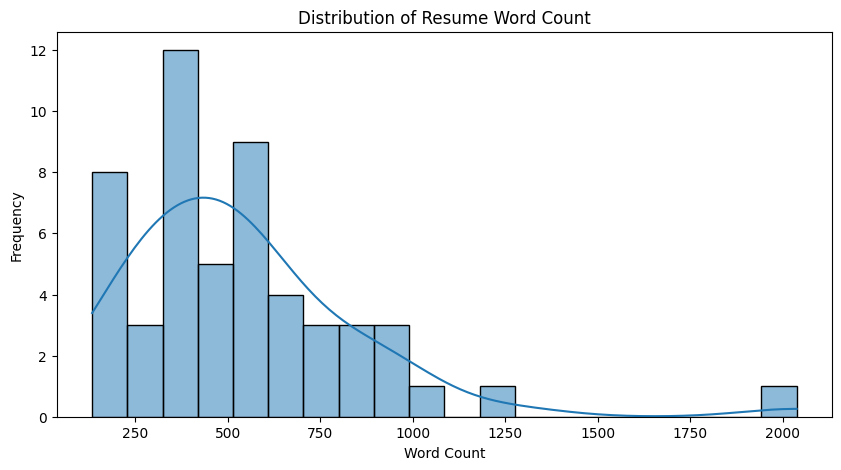

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], bins=20, kde=True)
plt.title("Distribution of Resume Word Count")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.show()

#### Resume Word Count Distribution – Observation

- The distribution is right-skewed, indicating the presence of longer resumes.
- Most resumes fall within the range of approximately 300 to 800 words.
- A small number of resumes exceed 1200 words, showing potential outliers.
- The long tail on the right suggests variability in resume length across candidates.

**Inference:**  
The dataset contains moderate variation in resume length, with a few significantly long resumes that may influence model training.

#

#### Outlier Detection (Word Count using IQR)

In [17]:
Q1 = df['word_count'].quantile(0.25)
Q3 = df['word_count'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)

print("\nLower Bound:", lower_bound)
print("Upper Bound:", upper_bound)

outliers = df[(df['word_count'] < lower_bound) | (df['word_count'] > upper_bound)]

print("\nNumber of Outlier Resumes:", outliers.shape[0])

Q1: 339.0
Q3: 630.0
IQR: 291.0

Lower Bound: -97.5
Upper Bound: 1066.5

Number of Outlier Resumes: 2


#### Outlier Detection – Observation

- Upper bound (IQR): 1066.5 words  
- 2 resumes identified as outliers  
- Outliers retained for further analysis

#

### Role-wise Word Count Distribution

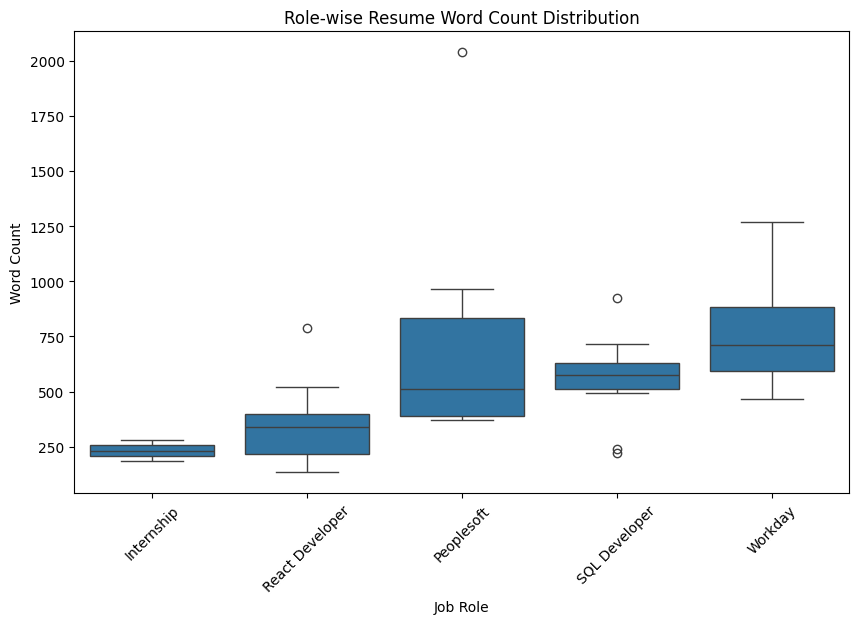

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.boxplot(x='job_title', y='word_count', data=df)

plt.title("Role-wise Resume Word Count Distribution")
plt.xlabel("Job Role")
plt.ylabel("Word Count")
plt.xticks(rotation=45)
plt.show()

#### Role-wise Resume Length – Observation

- Internship resumes are the shortest and most consistent.
- Workday and Peoplesoft resumes tend to be longer.
- Peoplesoft shows the highest variability with extreme outliers.
- Resume length varies significantly across job roles.

#

## STEP 3 – Raw Text Pattern Analysis

In [19]:
# Vocabulary Size Analysis (Raw Text)

from collections import Counter

all_words_raw = " ".join(df['resume_text']).lower().split()

unique_words_raw = set(all_words_raw)

print("Total Words (Raw):", len(all_words_raw))
print("Unique Words (Raw Vocabulary Size):", len(unique_words_raw))
print("Lexical Diversity (Unique / Total):", 
      round(len(unique_words_raw) / len(all_words_raw), 4))

Total Words (Raw): 28610
Unique Words (Raw Vocabulary Size): 5073
Lexical Diversity (Unique / Total): 0.1773


In [20]:
# Role-wise Vocabulary & Lexical Diversity

role_stats = []

for role in df['job_title'].unique():
    role_text = " ".join(df[df['job_title'] == role]['resume_text']).lower().split()
    
    total_words = len(role_text)
    unique_words = len(set(role_text))
    lexical_diversity = unique_words / total_words
    
    role_stats.append([role, total_words, unique_words, round(lexical_diversity, 4)])

import pandas as pd
role_vocab_df = pd.DataFrame(
    role_stats,
    columns=["Role", "Total Words", "Unique Words", "Lexical Diversity"]
)

role_vocab_df

,Role,Total Words,Unique Words,Lexical Diversity
0,Internship,464,269,0.5797
1,React Developer,6610,1968,0.2977
2,Peoplesoft,7022,1588,0.2261
3,SQL Developer,6086,1806,0.2967
4,Workday,8428,1701,0.2018


### Frequency Distribution Visualization

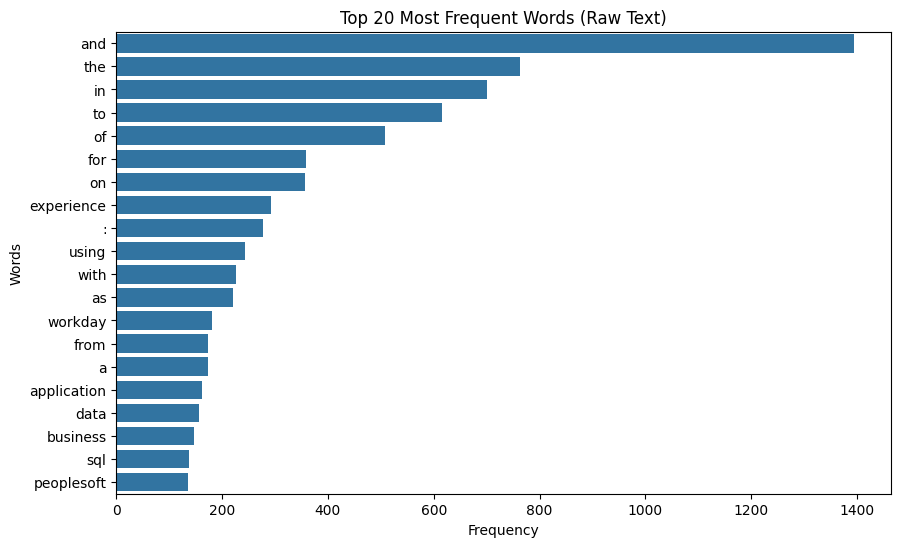

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

word_freq_raw = Counter(all_words_raw)
top_20_raw = word_freq_raw.most_common(20)

words = [w[0] for w in top_20_raw]
counts = [w[1] for w in top_20_raw]

plt.figure(figsize=(10,6))
sns.barplot(x=counts, y=words)
plt.title("Top 20 Most Frequent Words (Raw Text)")
plt.xlabel("Frequency")
plt.ylabel("Words")
plt.show()

### Bigram Frequency Analysis (Raw Text)

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(
    ngram_range=(2,2),
    stop_words='english',
    max_features=20
)

X_bigrams = vectorizer.fit_transform(df['resume_text'])

bigram_counts = X_bigrams.sum(axis=0).A1
bigram_terms = vectorizer.get_feature_names_out()

bigram_freq = sorted(
    zip(bigram_terms, bigram_counts),
    key=lambda x: x[1],
    reverse=True
)

print("Top 20 Bigrams:\n")
for term, count in bigram_freq:
    print(f"{term} : {count}")

Top 20 Bigrams:

sql server : 82
react js : 81
process scheduler : 49
custom reports : 35
good knowledge : 35
technical skills : 35
business process : 34
calculated fields : 34
server domains : 33
till date : 33
application server : 32
years experience : 32
hands experience : 31
workday hcm : 30
workday studio : 30
people tools : 27
roles responsibilities : 27
web server : 27
html5 css3 : 25
stored procedures : 25


### Role-wise Bigram Analysis

In [23]:
from sklearn.feature_extraction.text import CountVectorizer

for role in df['job_title'].unique():
    
    print(f"\nTop Bigrams for {role}:\n")
    
    role_text = df[df['job_title'] == role]['resume_text']
    
    vectorizer = CountVectorizer(
        ngram_range=(2,2),
        stop_words='english',
        max_features=10
    )
    
    X_role = vectorizer.fit_transform(role_text)
    
    bigram_counts = X_role.sum(axis=0).A1
    bigram_terms = vectorizer.get_feature_names_out()
    
    bigram_freq = sorted(
        zip(bigram_terms, bigram_counts),
        key=lambda x: x[1],
        reverse=True
    )
    
    for term, count in bigram_freq:
        print(f"{term} : {count}")


Top Bigrams for Internship:

good knowledge : 16
testing good : 5
test cases : 4
extreme knowledge : 3
html css : 3
integration test : 2
knowledge scrum : 2
meeting extreme : 2
meeting good : 2
website using : 2

Top Bigrams for React Developer:

react js : 81
html5 css3 : 25
html css : 19
using react : 18
css3 javascript : 15
js developer : 12
technical skills : 12
web pages : 12
web technologies : 11
ui developer : 10

Top Bigrams for Peoplesoft:

process scheduler : 45
server domains : 33
application server : 32
web server : 27
people tools : 26
experience peoplesoft : 22
scheduler servers : 21
application designer : 19
servers web : 18
domains process : 17

Top Bigrams for SQL Developer:

sql server : 78
stored procedures : 25
ms sql : 16
integration services : 12
sub queries : 12
till date : 12
defined functions : 11
server integration : 11
sql queries : 11
using sql : 11

Top Bigrams for Workday:

custom reports : 35
calculated fields : 34
business process : 32
workday hcm : 30


#

### Word Frequency Ranking

In [24]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from collections import Counter
import pandas as pd
import re

# Custom resume filler words to remove
custom_stopwords = {
    "experience", "using", "project", "projects", "knowledge",
    "good", "skills", "various", "like", "involved",
    "responsible", "worked", "team", "role"
}

# Combine text
text = " ".join(df['resume_text']).lower()

# Remove punctuation
text = re.sub(r'[^a-zA-Z\s]', '', text)

# Tokenize
words = text.split()

# Remove stopwords + custom filler words
filtered_words = [
    word for word in words
    if word not in ENGLISH_STOP_WORDS
    and word not in custom_stopwords
    and len(word) > 2
]

# Count frequency
word_freq = Counter(filtered_words)

# Top 20 technical terms
sorted_words = word_freq.most_common(20)

word_freq_df = pd.DataFrame(
    sorted_words,
    columns=["Technical Word", "Frequency"]
)

print("Top 20 Technical Domain Words:\n")
display(word_freq_df)

Top 20 Technical Domain Words:



,Technical Word,Frequency
0,workday,189
1,application,187
2,data,167
3,reports,163
4,server,161
5,business,154
6,sql,153
7,peoplesoft,152
8,web,119
9,process,117


### Role-wise WordCloud Visualization

In [25]:
import sys
!{sys.executable} -m pip install wordcloud


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



WordCloud for Internship



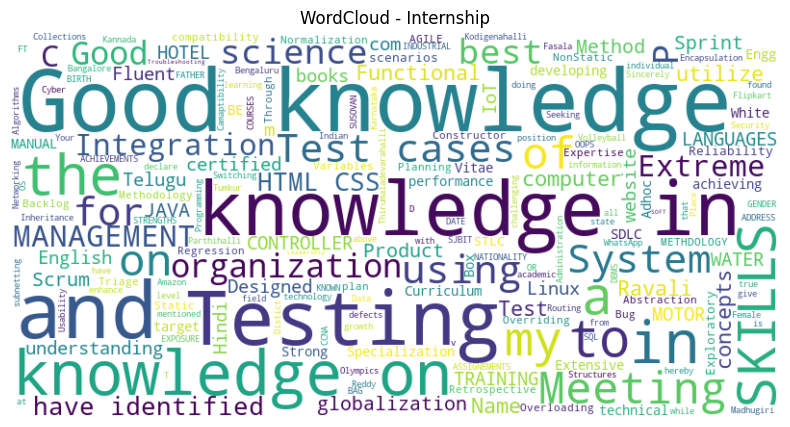


WordCloud for React Developer



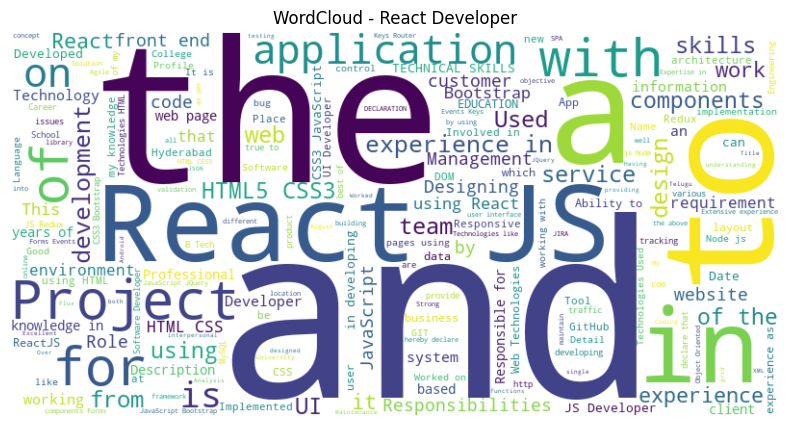


WordCloud for Peoplesoft



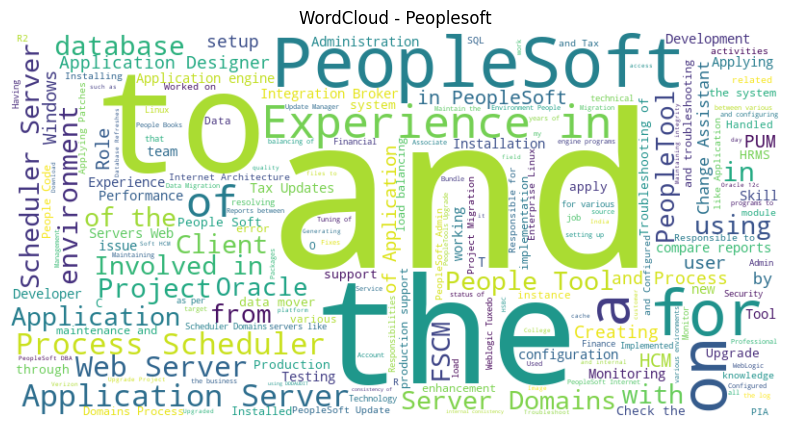


WordCloud for SQL Developer



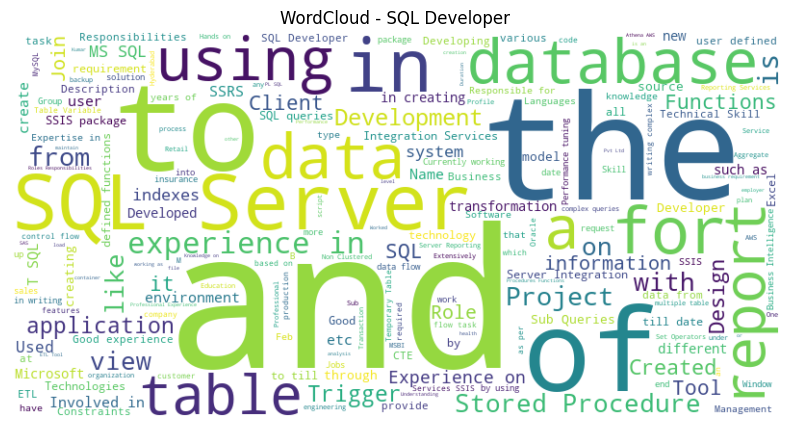


WordCloud for Workday



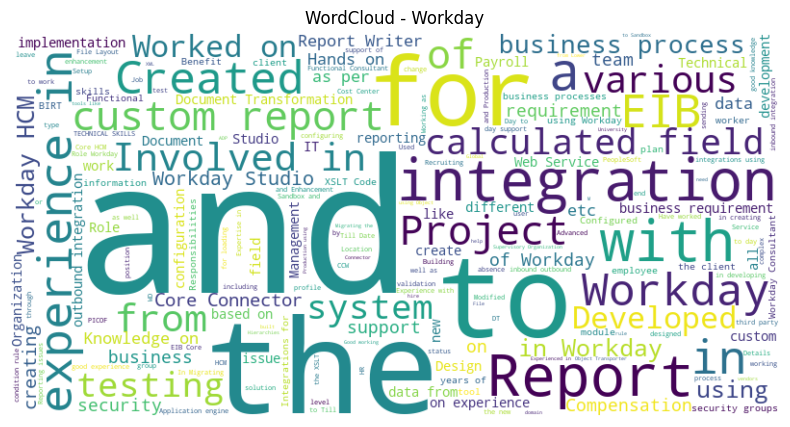

In [26]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

for role in df['job_title'].unique():
    
    print(f"\nWordCloud for {role}\n")
    
    role_text = " ".join(df[df['job_title'] == role]['resume_text'])
    
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        stopwords='english'
    ).generate(role_text)
    
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f"WordCloud - {role}")
    plt.show()

### Role Similarity Matrix (TF-IDF + Cosine Similarity)

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

# Combine resumes per role
role_texts = df.groupby('job_title')['resume_text'].apply(lambda x: " ".join(x))

# TF-IDF
tfidf = TfidfVectorizer(stop_words='english')
X_role = tfidf.fit_transform(role_texts)

# Cosine similarity
similarity_matrix = cosine_similarity(X_role)

similarity_df = pd.DataFrame(
    similarity_matrix,
    index=role_texts.index,
    columns=role_texts.index
)

similarity_df.round(2)

job_title,Internship,Peoplesoft,React Developer,SQL Developer,Workday
job_title,,,,,
Internship,1.00,0.08,0.16,0.12,0.12
Peoplesoft,0.08,1.00,0.20,0.32,0.26
React Developer,0.16,0.20,1.00,0.25,0.18
SQL Developer,0.12,0.32,0.25,1.00,0.27
Workday,0.12,0.26,0.18,0.27,1.00


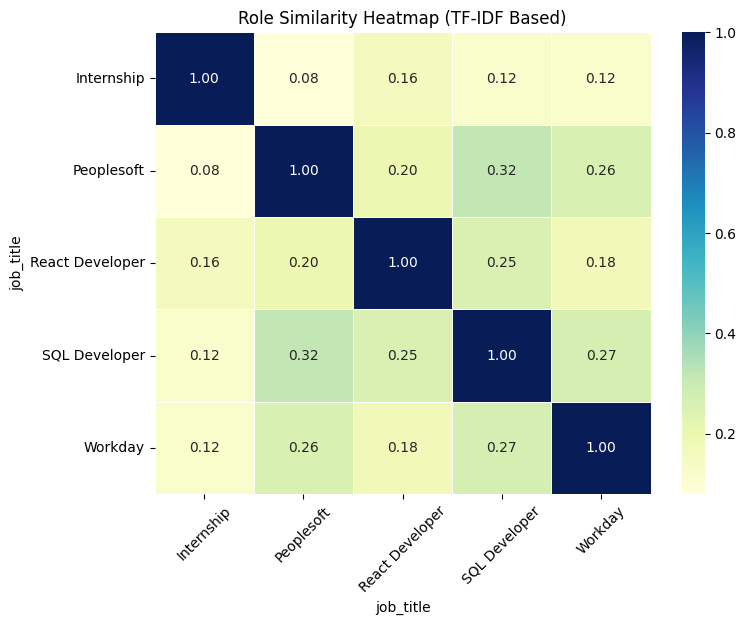

In [28]:
# Role similarity heatmap

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    similarity_df,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Role Similarity Heatmap (TF-IDF Based)")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()

#### Role Similarity Matrix – Observation

- Peoplesoft and SQL Developer show the highest similarity (0.32), indicating overlapping database-related terminology.
- SQL Developer and Workday also show moderate similarity.
- Internship resumes are the most distinct from other roles.
- Overall, role vocabulary shows strong separability, supporting effective classification.

#

### PCA Visualization (Role Clustering)

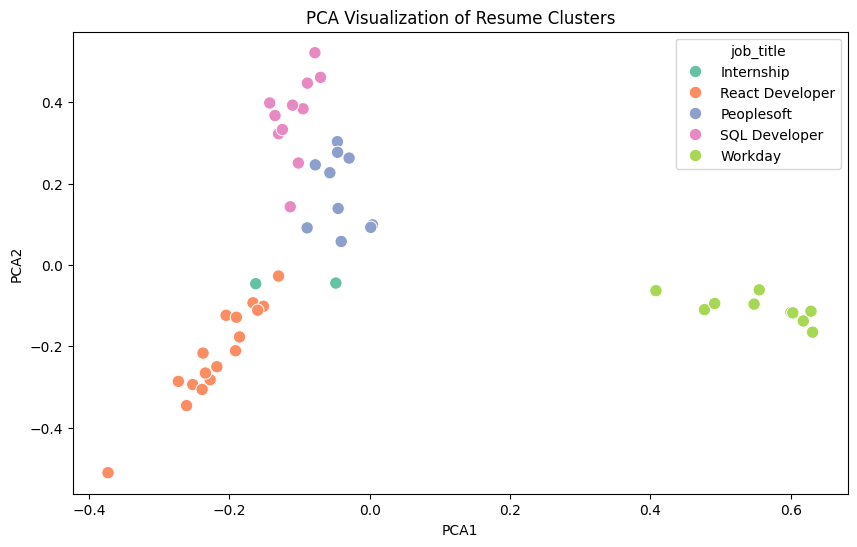

In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF on individual resumes
tfidf = TfidfVectorizer(stop_words='english', max_features=3000)
X = tfidf.fit_transform(df['resume_text'])

# Convert sparse matrix to dense (required for PCA)
X_dense = X.toarray()

# Apply PCA
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_dense)

# Add PCA results to dataframe
df['PCA1'] = X_pca[:, 0]
df['PCA2'] = X_pca[:, 1]

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='job_title',
    data=df,
    palette='Set2',
    s=80
)

plt.title("PCA Visualization of Resume Clusters")
plt.show()

#### PCA Visualization – Observation

- Workday and React Developer resumes form clearly separated clusters.
- SQL Developer and Peoplesoft clusters are relatively closer, indicating vocabulary overlap.
- Internship resumes appear distinct but limited in number.
- Overall, resume roles show strong separability, supporting effective classification modeling.

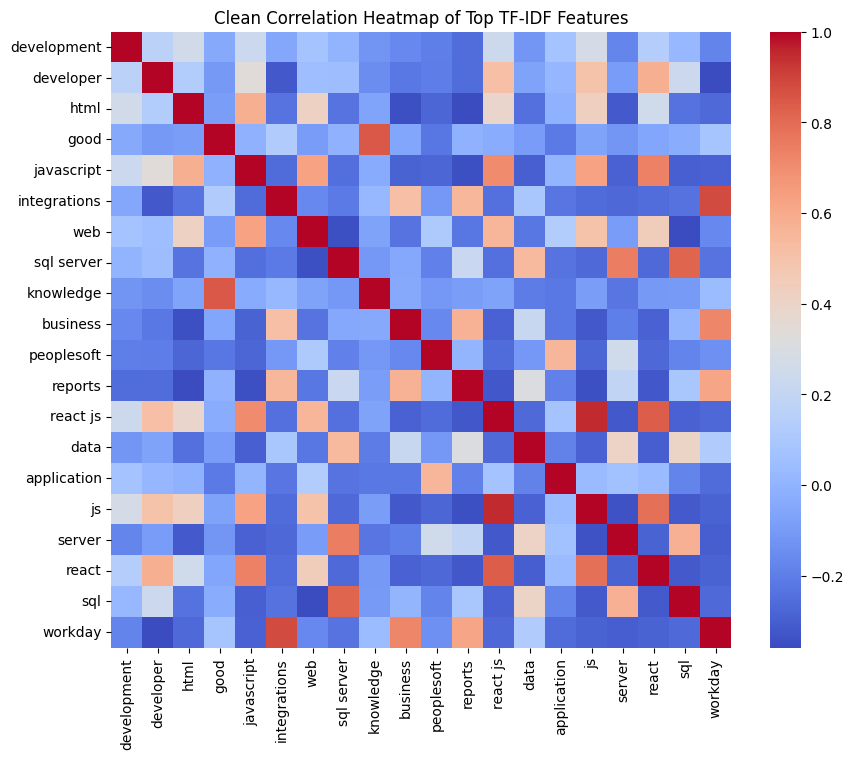

In [30]:
# Top TF-IDF Feature Correlation Heatmap

from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Proper filtered TF-IDF
tfidf_clean = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),
    max_features=2000,
    min_df=2,
    max_df=0.8
)

X_clean = tfidf_clean.fit_transform(df['resume_text'])

feature_names = tfidf_clean.get_feature_names_out()
tfidf_dense = X_clean.toarray()

# Get top 20 important features
avg_scores = np.mean(tfidf_dense, axis=0)
top_indices = np.argsort(avg_scores)[-20:]

top_features = [feature_names[i] for i in top_indices]

top_df = pd.DataFrame(
    tfidf_dense[:, top_indices],
    columns=top_features
)

corr = top_df.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", annot=False)
plt.title("Clean Correlation Heatmap of Top TF-IDF Features")
plt.show()

### Correlation Heatmap of Top TF-IDF Features – Observation

- Strong positive correlations are visible between related technical terms (e.g., react & javascript, sql & sql server).
- Domain-specific keywords such as workday, peoplesoft, and reports show structured association patterns.
- Feature clusters indicate meaningful co-occurrence of skills within resumes.
- Correlation patterns support the separability of different job roles.

#

## Final EDA Summary – Resume Classification

- Total resumes analyzed: **53** across 5 job roles.
- No missing values or duplicate entries detected.

- Average resume length: **~540 words**, with 2 length outliers.
- Role-wise lexical diversity shows:
  - Higher variation in **Internship** resumes.
  - More standardized terminology in **Workday** and **Peoplesoft** roles.

- Bigram analysis identified strong role-specific skill patterns such as:
  - *react js*, *sql server*, *workday hcm*, *process scheduler*.

- Cosine similarity and PCA visualization confirm:
  - Clear separation between most roles.
  - Moderate similarity between **SQL Developer** and **Peoplesoft**.

### Conclusion
Resume roles demonstrate distinct vocabulary patterns, supporting effective supervised classification.

#

## Feature Engineering and Text Vectorization 

### TF-IDF Feature Engineering

In [31]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Advanced TF-IDF configuration
tfidf = TfidfVectorizer(
    stop_words='english',
    ngram_range=(1,2),      # Unigrams + Bigrams
    max_features=3000,      # Limit feature space
    min_df=2,               # Ignore rare terms
    max_df=0.9              # Ignore overly common terms
)

X = tfidf.fit_transform(df['resume_text'])
y = df['job_title']

print("TF-IDF Feature Matrix Shape:", X.shape)
print("Total Features Generated:", len(tfidf.get_feature_names_out()))

TF-IDF Feature Matrix Shape: (53, 3000)
Total Features Generated: 3000


### Class-wise Discriminative TF-IDF Features 

In [32]:
import numpy as np
import pandas as pd

feature_names = tfidf.get_feature_names_out()

tfidf_df = pd.DataFrame(X.toarray(), columns=feature_names)
tfidf_df['job_title'] = y.values

for role in tfidf_df['job_title'].unique():
    print(f"\nTop 10 Discriminative Features for {role}:\n")
    
    role_data = tfidf_df[tfidf_df['job_title'] == role]
    mean_scores = role_data.drop(columns=['job_title']).mean()
    
    top_features = (
        mean_scores
        .sort_values(ascending=False)
        .head(10)
        .reset_index()
    )
    
    top_features.columns = ['Feature', 'Average TF-IDF Score']
    
    display(top_features)


Top 10 Discriminative Features for Internship:



,Feature,Average TF-IDF Score
0,good knowledge,0.263027
1,knowledge,0.220956
2,good,0.198341
3,testing,0.153091
4,hotel,0.110465
5,html css,0.110359
6,books,0.102296
7,website using,0.095960
8,css,0.094400
9,skills,0.092706



Top 10 Discriminative Features for React Developer:



,Feature,Average TF-IDF Score
0,react,0.180995
1,js,0.137849
2,react js,0.116635
3,javascript,0.084355
4,html,0.069981
5,ui,0.068809
6,web,0.064160
7,css3,0.063005
8,bootstrap,0.060275
9,using,0.057267



Top 10 Discriminative Features for Peoplesoft:



,Feature,Average TF-IDF Score
0,peoplesoft,0.197711
1,application,0.110702
2,people,0.099810
3,server,0.095186
4,servers,0.093685
5,oracle,0.069702
6,tools,0.065285
7,people tools,0.063621
8,process,0.061344
9,peopletools,0.060767



Top 10 Discriminative Features for SQL Developer:



,Feature,Average TF-IDF Score
0,sql,0.304547
1,sql server,0.168835
2,server,0.151036
3,data,0.102271
4,tables,0.088794
5,functions,0.085723
6,database,0.085466
7,indexes,0.079592
8,ssis,0.077247
9,procedures,0.076182



Top 10 Discriminative Features for Workday:



,Feature,Average TF-IDF Score
0,workday,0.362496
1,integrations,0.169356
2,reports,0.119369
3,eib,0.116197
4,business,0.103484
5,custom,0.093708
6,core,0.086490
7,report,0.084881
8,fields,0.083753
9,hcm,0.081018


#

###  Sparsity Check

In [33]:
import numpy as np

total_elements = X.shape[0] * X.shape[1]
non_zero_elements = X.count_nonzero()

sparsity = 1 - (non_zero_elements / total_elements)

print("Total Elements:", total_elements)
print("Non-Zero Elements:", non_zero_elements)
print("Sparsity Level:", round(sparsity, 4))

Total Elements: 159000
Non-Zero Elements: 14613
Sparsity Level: 0.9081


### Label Encoding

In [34]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label Mapping:")
for role, encoded in zip(le.classes_, le.transform(le.classes_)):
    print(f"{role} -> {encoded}")

Label Mapping:
Internship -> 0
Peoplesoft -> 1
React Developer -> 2
SQL Developer -> 3
Workday -> 4


#

### Feature Engineering & Text Vectorization Summary 

Resume text was transformed into numerical vectors using TF-IDF vectorization.
Both unigrams and bigrams (ngram_range = 1,2) were used to capture
individual technical skills as well as skill combinations.

Dimensionality was controlled using:
- max_features = 3000
- min_df = 2
- max_df = 0.9

Generated feature matrix shape: (53, 3000)
Feature sparsity level: ~91%
Target labels encoded using LabelEncoder for supervised classification.

#

## MODEL TRAINING 

### Train Test Split

In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training Set Shape:", X_train.shape)
print("Testing Set Shape:", X_test.shape)

Training Set Shape: (42, 3000)
Testing Set Shape: (11, 3000)


#

### Model 1 – Logistic Regression
Logistic Regression is used as a baseline linear classifier suitable for high-dimensional TF-IDF features.

In [36]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=2000)

In [37]:
log_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [38]:
# Logistic Regression Accuracy

from sklearn.metrics import accuracy_score

# Prediction on test data
y_pred_log = log_model.predict(X_test)

# Accuracy
log_accuracy = accuracy_score(y_test, y_pred_log)

print("Logistic Regression Accuracy:", log_accuracy)

Logistic Regression Accuracy: 0.8181818181818182


#

### Model 2 – Linear Support Vector Machine (SVM)

Linear SVM is highly effective for high-dimensional sparse TF-IDF text features.

In [39]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

In [40]:
svm_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [41]:
# Linear SVM Accuracy

y_pred_svm = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, y_pred_svm)

print("Linear SVM Accuracy:", svm_accuracy)

Linear SVM Accuracy: 0.9090909090909091


#

### Model 3 – Multinomial Naive Bayes

Multinomial Naive Bayes is a probabilistic classifier commonly used for text classification tasks.

In [42]:
from sklearn.naive_bayes import MultinomialNB

nb_model = MultinomialNB()

In [43]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [44]:
# Naive Bayes Accuracy

from sklearn.metrics import accuracy_score

# Prediction
y_pred_nb = nb_model.predict(X_test)

# Accuracy
nb_accuracy = accuracy_score(y_test, y_pred_nb)

print("Multinomial Naive Bayes Accuracy:", nb_accuracy)

Multinomial Naive Bayes Accuracy: 0.8181818181818182


#

### Model 4 – Random Forest

Random Forest is an ensemble learning model that combines multiple decision trees to improve classification performance.

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

In [46]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [47]:
# Random Forest Accuracy

from sklearn.metrics import accuracy_score

y_pred_rf = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

Random Forest Accuracy: 0.9090909090909091


#

### MODEL SELECTION

In [48]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        log_accuracy,
        nb_accuracy,
        svm_accuracy,
        rf_accuracy
    ]
})

comparison_df

,Model,Accuracy
0,Logistic Regression,0.818182
1,Multinomial Naive Bayes,0.818182
2,Linear SVM,0.909091
3,Random Forest,0.909091


#

### Model Training

To develop the Resume Classification System, four supervised machine learning models were trained using TF-IDF features (unigrams and bigrams):

- Logistic Regression  
- Multinomial Naive Bayes  
- Linear Support Vector Machine (SVM)  
- Random Forest  

The dataset was split into 80% training and 20% testing sets using stratified sampling to maintain class distribution and ensure unbiased evaluation.

#### Performance Comparison (Test Accuracy)

- Logistic Regression: 81.81%  
- Multinomial Naive Bayes: 81.81%  
- Linear SVM: 90.90%  
- Random Forest: 90.90%  

Linear SVM and Random Forest outperformed the other models in initial testing.

### Cross Validation – Model Stability Check

In [49]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
import numpy as np

skf = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

# Linear SVM
svm_cv_scores = cross_val_score(svm_model, X, y_encoded, cv=skf)
print("Linear SVM CV Scores:", svm_cv_scores)
print("Linear SVM Average CV Accuracy:", np.mean(svm_cv_scores))

print("--------------------------------------------------")

# Random Forest
rf_cv_scores = cross_val_score(rf_model, X, y_encoded, cv=skf)
print("Random Forest CV Scores:", rf_cv_scores)
print("Random Forest Average CV Accuracy:", np.mean(rf_cv_scores))

Linear SVM CV Scores: [0.88888889 0.96153846]
Linear SVM Average CV Accuracy: 0.9252136752136753
--------------------------------------------------
Random Forest CV Scores: [0.85185185 0.96153846]
Random Forest Average CV Accuracy: 0.9066951566951567


### Model Selection

#### Cross-Validation for Stability

To validate model generalization, Stratified 2-Fold Cross-Validation was conducted:

- Linear SVM Average CV Accuracy: 92.52%  
- Random Forest Average CV Accuracy: 90.67%  

#### Final Model Selection

Linear SVM achieved the highest cross-validation accuracy and demonstrated more consistent performance on high-dimensional sparse TF-IDF features.  

Therefore, Linear SVM was selected as the final production model to ensure accurate, stable, and automated resume classification aligned with the business objective of reducing manual HR effort.

#

## MODEL EVALUATION

In [50]:
from sklearn.metrics import classification_report

y_pred_final = svm_model.predict(X_test)

print("Classification Report – Linear SVM:\n")
print(classification_report(
    y_test, 
    y_pred_final, 
    target_names=le.classes_,
    zero_division=0
))

Classification Report – Linear SVM:

                 precision    recall  f1-score   support

     Internship       0.00      0.00      0.00         1
     Peoplesoft       1.00      1.00      1.00         2
React Developer       0.80      1.00      0.89         4
  SQL Developer       1.00      1.00      1.00         2
        Workday       1.00      1.00      1.00         2

       accuracy                           0.91        11
      macro avg       0.76      0.80      0.78        11
   weighted avg       0.84      0.91      0.87        11



#

#### Confusion Matrix – Linear SVM

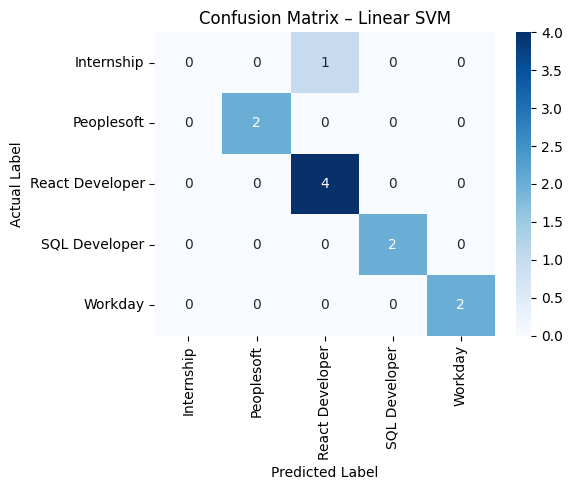

In [51]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title("Confusion Matrix – Linear SVM")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()

### Model Evaluation Summary

The Linear SVM model achieved 90.90% test accuracy with strong performance across major job roles. 

All technical categories were correctly classified. The only misclassification occurred in the Internship category due to very limited training samples.

Overall, the model demonstrates reliable and accurate resume classification performance.

#

## DEPLOYMENT 

In [52]:
import pickle

# Save trained SVM model
pickle.dump(svm_model, open("resume_model.pkl", "wb"))

# Save TF-IDF vectorizer
pickle.dump(tfidf, open("tfidf_vectorizer.pkl", "wb"))

# Save label encoder
pickle.dump(le, open("label_encoder.pkl", "wb"))